# Part 8 — Model Evaluation and Comparison

**7PAM2033 Applied Machine Learning — Assignment 2**

> **Task:** Evaluate all models using common accuracy metrics, forecast plots,
> error diagnostics, and comparison against the strongest benchmark model.

Every model from Parts 3, 4, 6 and 7 forecast the same 336 held-out hours from
the same 14 origins, so their errors are directly comparable without
re-running anything. This notebook pools them and asks four questions:

1. How do the models rank, and by how much?
2. Which differences are real rather than sampling noise?
3. Where does each model fail — which hours, which lead times, which demand levels?
4. Does anything justify its complexity against the strongest benchmark?

The last question is the one that matters. A ranking table on its own says
very little when the day-to-day spread in accuracy is larger than the gaps
between models, which Parts 3 to 7 each found in turn.


## 1. Setup


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

BASE_DIR = Path.cwd()
HOURLY_FILE = BASE_DIR / "energy_hourly.csv"
RAW_FILE = BASE_DIR / "energydata_complete.csv"
RAW_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "00374/energydata_complete.csv")

FIGURE_DIR = BASE_DIR / "outputs" / "figures"
METRICS_DIR = BASE_DIR / "outputs" / "metrics"
FORECAST_DIR = BASE_DIR / "outputs" / "forecasts"
for directory in (FIGURE_DIR, METRICS_DIR, FORECAST_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TARGET = "Appliances"
NOISE_COLS = ["rv1", "rv2"]
OBS_PER_HOUR = 6
_PV = tuple(int(p) for p in pd.__version__.split(".")[:2])
HOURLY_FREQ = "h" if _PV >= (2, 2) else "H"

DAILY_PERIOD, WEEKLY_PERIOD = 24, 168
HORIZON, TEST_DAYS = 24, 14
TEST_STEPS = TEST_DAYS * DAILY_PERIOD

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11, "axes.titlesize": 12})
PRIMARY, SECONDARY, MUTED = "#1f4e79", "#c0504d", "#7f9db9"

FAMILY_COLOURS = {"benchmark": "#8c8c8c", "sarimax": "#1f4e79",
                  "machine learning": "#2e8b57", "foundation": "#c0504d"}


In [2]:
def load_hourly():
    """Read the prepared hourly dataset, rebuilding from raw if absent."""
    if HOURLY_FILE.exists():
        frame = pd.read_csv(HOURLY_FILE, parse_dates=["date"], index_col="date")
        return frame.asfreq(HOURLY_FREQ)
    if not RAW_FILE.exists():
        pd.read_csv(RAW_URL).to_csv(RAW_FILE, index=False)
    raw = pd.read_csv(RAW_FILE, parse_dates=["date"]).set_index("date").sort_index()
    raw = raw.drop(columns=[c for c in NOISE_COLS if c in raw.columns])
    counts = raw.resample(HOURLY_FREQ).size()
    hourly = raw.resample(HOURLY_FREQ).mean().loc[counts >= OBS_PER_HOUR]
    hourly = hourly.dropna(subset=[TARGET]); hourly.to_csv(HOURLY_FILE)
    return hourly


hourly = load_hourly()
series = hourly[TARGET]
train_series = series.iloc[:-TEST_STEPS]
test_series = series.iloc[-TEST_STEPS:]

scale_values = np.asarray(train_series, dtype=float)
MASE_SCALE = float(np.mean(np.abs(scale_values[DAILY_PERIOD:] -
                                  scale_values[:-DAILY_PERIOD])))

print(f"Test period  : {test_series.index.min()} to {test_series.index.max()}")
print(f"Test hours   : {len(test_series)}")
print(f"Test mean    : {test_series.mean():.1f} Wh")
print(f"Test std     : {test_series.std():.1f} Wh")
print(f"MASE scale   : {MASE_SCALE:.3f} Wh")


Test period  : 2016-05-13 18:00:00 to 2016-05-27 17:00:00
Test hours   : 336
Test mean    : 100.3 Wh
Test std     : 74.0 Wh
MASE scale   : 53.359 Wh


## 2. Pooling every forecast

Each earlier notebook wrote its predictions to `outputs/forecasts/`. If a file
is missing, that family is reported and skipped rather than silently omitted —
an incomplete comparison should be visible, not invisible.


In [3]:
SOURCES = {
    "part3_benchmark_forecasts.csv": "benchmark",
    "part4_sarimax_forecasts.csv": "sarimax",
    "part6_ml_forecasts.csv": "machine learning",
    "part7_chronos_forecasts.csv": "foundation",
}


def collect_forecasts(sources=SOURCES):
    """Gather every part's forecasts onto a common index."""
    frames, missing = [], []

    for filename, family in sources.items():
        path = FORECAST_DIR / filename
        if not path.exists():
            missing.append(filename)
            print(f"  MISSING : {filename}")
            continue
        frame = pd.read_csv(path, parse_dates=["timestamp"])
        frame["family"] = family
        frames.append(frame)
        print(f"  loaded  : {filename:<38} "
              f"{frame['model'].nunique()} models")

    if not frames:
        raise FileNotFoundError(
            f"No forecast files found in {FORECAST_DIR}. Run Parts 3 to 7 "
            f"first, or copy their CSVs into that folder.")

    combined = pd.concat(frames, ignore_index=True)

    # Only models covering the full test window can be compared fairly
    counts = combined.groupby("model").size()
    incomplete = counts[counts != TEST_STEPS]
    if len(incomplete):
        print(f"\n  dropped (incomplete coverage): {list(incomplete.index)}")
        combined = combined[~combined["model"].isin(incomplete.index)]

    return combined, missing


forecasts, missing_files = collect_forecasts()

print(f"\nModels compared : {forecasts['model'].nunique()}")
print(f"Predictions     : {len(forecasts)}")
if missing_files:
    print(f"\nIncomplete comparison - {len(missing_files)} family file(s) absent.")


  loaded  : part3_benchmark_forecasts.csv          5 models
  MISSING : part4_sarimax_forecasts.csv
  loaded  : part6_ml_forecasts.csv                 3 models
  loaded  : part7_chronos_forecasts.csv            1 models

Models compared : 9
Predictions     : 3024

Incomplete comparison - 1 family file(s) absent.


## 3. Accuracy metrics

Five point metrics and two interval metrics, as fixed in Part 2. The skill
score is added here: the proportional reduction in MAE relative to the
strongest benchmark, which expresses "is the complexity worth it" as a single
number. Positive means better than the benchmark, negative means worse.


In [4]:
def evaluate(name, group, scale=None):
    """Point and interval metrics for one model's forecasts."""
    scale = MASE_SCALE if scale is None else scale
    actual = group["actual"].to_numpy(dtype=float)
    predicted = group["prediction"].to_numpy(dtype=float)
    error = actual - predicted

    record = {"model": name,
              "MAE": float(np.mean(np.abs(error))),
              "RMSE": float(np.sqrt(np.mean(error ** 2))),
              "MASE": float(np.mean(np.abs(error)) / scale),
              "sMAPE": float(np.mean(np.abs(error) /
                                     ((np.abs(actual) + np.abs(predicted)) / 2)) * 100),
              "Bias": float(np.mean(predicted - actual))}

    if "lower" in group.columns and group["lower"].notna().all():
        inside = ((actual >= group["lower"].to_numpy()) &
                  (actual <= group["upper"].to_numpy()))
        record["PICP"] = float(np.mean(inside))
        record["MPIW"] = float(np.mean(group["upper"] - group["lower"]))

    return record


scores = pd.DataFrame([
    {**evaluate(model, group), "family": group["family"].iloc[0]}
    for model, group in forecasts.groupby("model")
]).sort_values("MAE").reset_index(drop=True)

# Strongest benchmark: the reference every other model must beat
benchmarks = scores[scores["family"] == "benchmark"]
BEST_BENCHMARK = benchmarks.iloc[0]["model"] if len(benchmarks) else None
BENCHMARK_MAE = benchmarks.iloc[0]["MAE"] if len(benchmarks) else np.nan

scores["skill vs benchmark %"] = (1 - scores["MAE"] / BENCHMARK_MAE) * 100
scores["rank"] = range(1, len(scores) + 1)

columns = ["rank", "family", "model", "MAE", "RMSE", "MASE", "sMAPE",
           "Bias", "skill vs benchmark %"]
scores.to_csv(METRICS_DIR / "part8_master_comparison.csv", index=False)

print(f"Strongest benchmark: {BEST_BENCHMARK} (MAE {BENCHMARK_MAE:.2f} Wh)")
print("=" * 108)
print(scores[columns].round(3).to_string(index=False))


Strongest benchmark: seasonal_naive_weekly (MAE 42.92 Wh)
 rank           family                          model     MAE    RMSE  MASE  sMAPE    Bias  skill vs benchmark %
    1       foundation               chronos_zeroshot  33.580  67.528 0.629 26.006 -18.053                21.765
    2 machine learning hist_gradient_boosting_regimeB  36.552  61.510 0.685 30.547   2.996                14.839
    3 machine learning                  random_forest  39.365  64.059 0.738 31.695   2.220                 8.286
    4 machine learning         hist_gradient_boosting  40.030  65.803 0.750 32.525   0.733                 6.738
    5        benchmark          seasonal_naive_weekly  42.922  79.668 0.804 32.672 -12.624                 0.000
    6        benchmark           seasonal_naive_daily  48.393  85.790 0.907 35.571   1.667               -12.747
    7        benchmark                           mean  50.010  73.986 0.937 46.243  -3.061               -16.515
    8        benchmark                

In [5]:
interval_models = scores[scores["PICP"].notna()] if "PICP" in scores else pd.DataFrame()

if len(interval_models):
    print("Models producing prediction intervals")
    print("=" * 74)
    print(interval_models[["model", "PICP", "MPIW"]].round(3).to_string(index=False))
    print("\nNote: nominal levels differ between models (SARIMA 95%, "
          "Chronos 80%),")
    print("so widths are not directly comparable without rescaling - "
          "see Part 7 section 7.")
else:
    print("No interval forecasts available in the pooled set.")


Models producing prediction intervals
           model  PICP   MPIW
chronos_zeroshot 0.815 94.356

Note: nominal levels differ between models (SARIMA 95%, Chronos 80%),
so widths are not directly comparable without rescaling - see Part 7 section 7.


## 4. Stability across origins

A pooled mean hides how consistent a model is. The per-origin spread matters
for two reasons: operationally, a model that is usually excellent but
occasionally terrible may be worse than a steady one; and statistically, the
spread sets the scale against which differences between models must be judged.


In [6]:
per_origin = pd.DataFrame([
    {**evaluate(model, group), "origin_id": origin_id,
     "family": group["family"].iloc[0]}
    for (model, origin_id), group in forecasts.groupby(["model", "origin_id"])
])
per_origin.to_csv(METRICS_DIR / "part8_by_origin.csv", index=False)

stability = (per_origin.groupby("model")["MAE"]
             .agg(mean="mean", std="std", min="min", max="max")
             .assign(spread=lambda d: d["max"] - d["min"],
                     cv=lambda d: d["std"] / d["mean"])
             .sort_values("mean"))

print("MAE across the 14 daily origins (Wh)")
print("=" * 88)
print(stability.round(2).to_string())

typical_std = stability["std"].median()
best_gap = scores["MAE"].iloc[1] - scores["MAE"].iloc[0]
print(f"\nTypical day-to-day standard deviation : {typical_std:.1f} Wh")
print(f"Gap between the top two models        : {best_gap:.1f} Wh")
print(f"Ratio                                 : {best_gap / typical_std:.2f}")
print("\nA ratio well below 1 means the ranking at the top is not resolvable.")


MAE across the 14 daily origins (Wh)
                                  mean    std    min     max  spread    cv
model                                                                     
chronos_zeroshot                 33.58  22.46   6.30   83.63   77.33  0.67
hist_gradient_boosting_regimeB   36.55  18.79  12.31   79.75   67.44  0.51
random_forest                    39.37  19.52  14.28   80.03   65.75  0.50
hist_gradient_boosting           40.03  18.89  15.25   78.88   63.63  0.47
seasonal_naive_weekly            42.92  28.24   7.01   97.64   90.63  0.66
seasonal_naive_daily             48.39  24.51  14.93   94.38   79.44  0.51
mean                             50.01  20.33  31.08   97.88   66.80  0.41
naive                           143.38  76.48  48.68  308.89  260.21  0.53
drift                           143.94  76.90  48.64  310.36  261.72  0.53

Typical day-to-day standard deviation : 22.5 Wh
Gap between the top two models        : 3.0 Wh
Ratio                                 : 0.

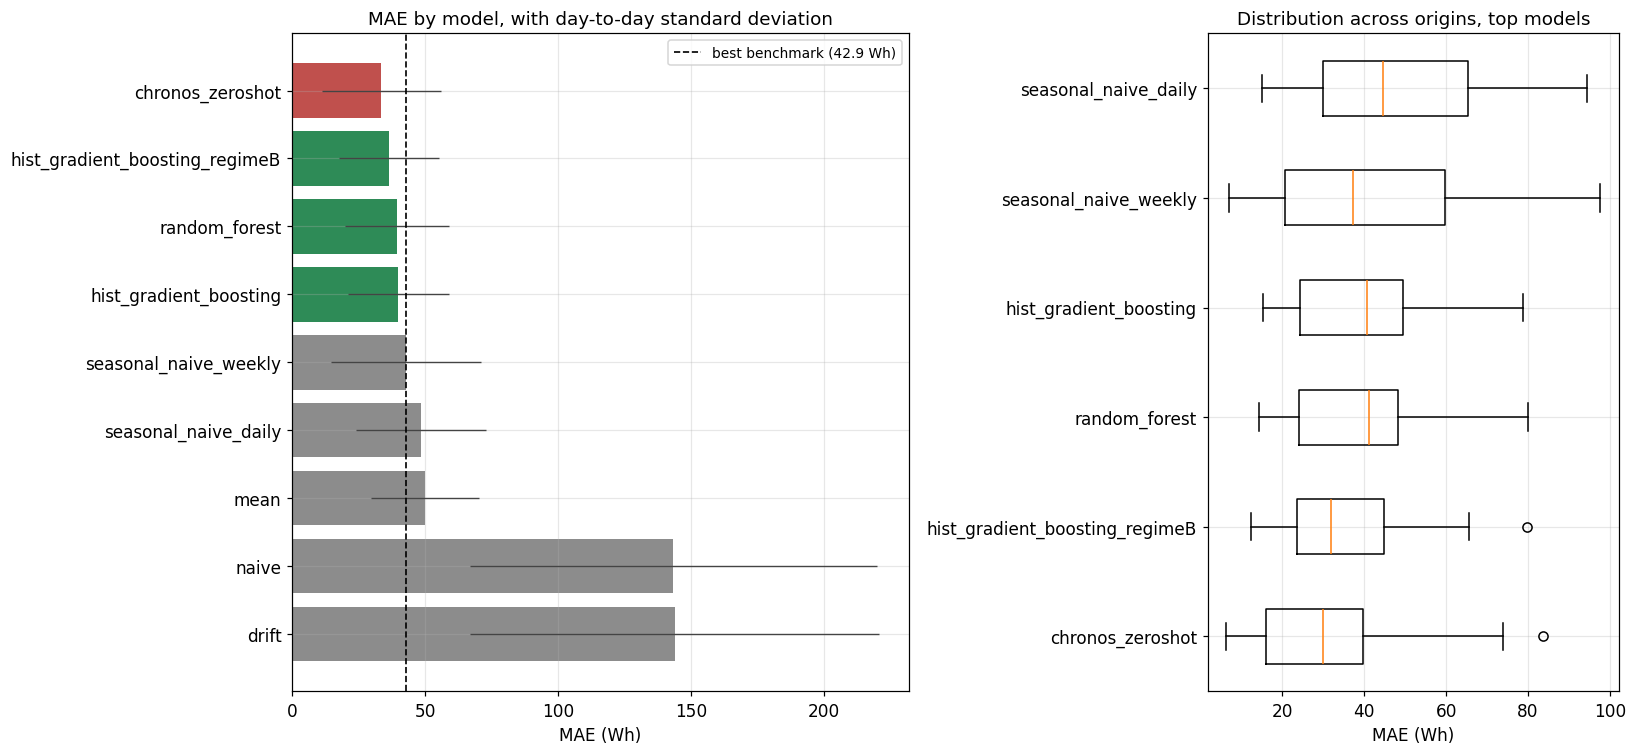

In [7]:
def plot_ranking(frame, stability_frame):
    """Ranked MAE with per-origin variability shown alongside."""
    ordered = frame.sort_values("MAE", ascending=False)
    errors = stability_frame.reindex(ordered["model"])["std"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 7),
                             gridspec_kw={"width_ratios": [3, 2]})

    axes[0].barh(ordered["model"], ordered["MAE"], xerr=errors,
                 color=[FAMILY_COLOURS.get(f, "#999") for f in ordered["family"]],
                 error_kw={"linewidth": 0.9, "ecolor": "#444"})
    if BEST_BENCHMARK:
        axes[0].axvline(BENCHMARK_MAE, color="black", linestyle="--",
                        linewidth=1.1,
                        label=f"best benchmark ({BENCHMARK_MAE:.1f} Wh)")
        axes[0].legend(fontsize=9)
    axes[0].set(title="MAE by model, with day-to-day standard deviation",
                xlabel="MAE (Wh)")

    top = frame.nsmallest(min(6, len(frame)), "MAE")["model"]
    box_data = [per_origin[per_origin["model"] == m]["MAE"].to_numpy()
                for m in top]
    axes[1].boxplot(box_data, tick_labels=list(top), vert=False)
    axes[1].set(title="Distribution across origins, top models",
                xlabel="MAE (Wh)")

    fig.tight_layout()
    return fig


fig = plot_ranking(scores, stability)
fig.savefig(FIGURE_DIR / "28_model_ranking.png")
plt.show()


## 5. Significance testing

Diebold–Mariano tests every pair of models, so the ranking can be read as
groups of statistically indistinguishable models rather than a strict order.


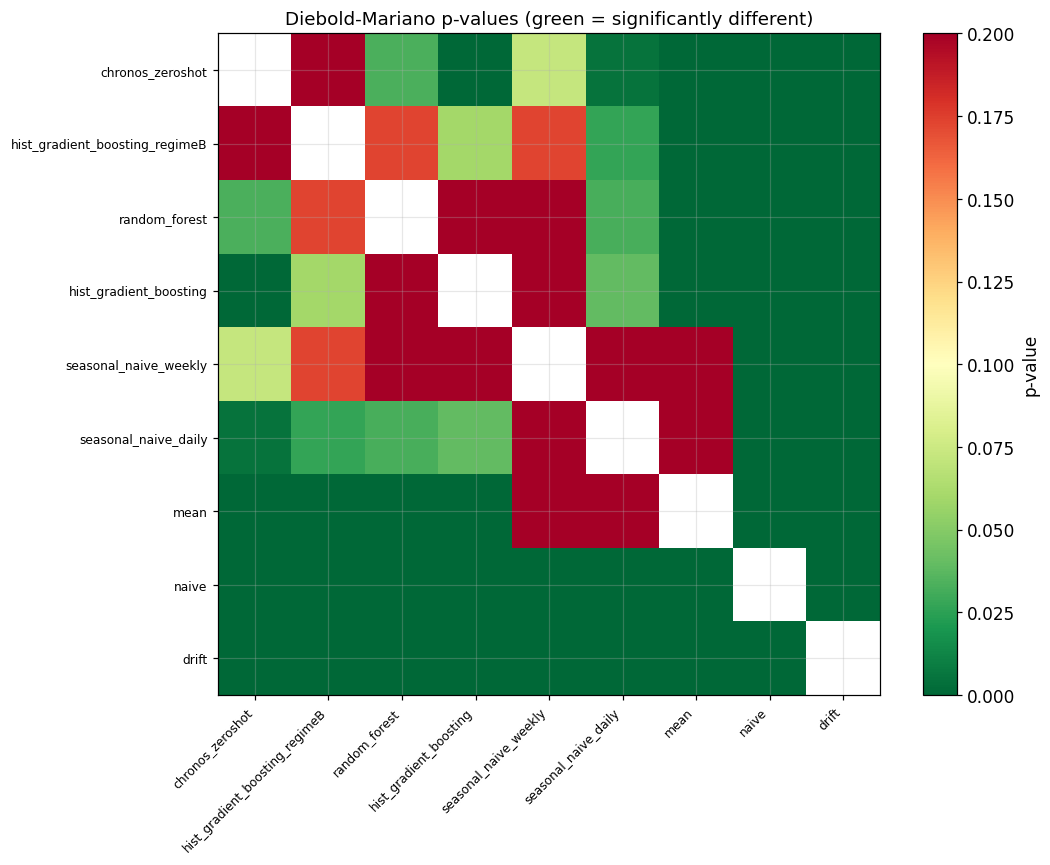

Pairs tested: 36
Significantly different at 5%: 25


In [8]:
def diebold_mariano(errors_a, errors_b, horizon=HORIZON, power=1):
    """DM test with HLN correction. Negative statistic favours model A."""
    differential = np.abs(errors_a) ** power - np.abs(errors_b) ** power
    n = len(differential)
    variance = np.var(differential, ddof=0)
    for lag in range(1, horizon):
        variance += 2 * np.cov(differential[lag:], differential[:-lag])[0, 1]
    if variance <= 0:
        return float("nan"), float("nan")
    statistic = differential.mean() / np.sqrt(variance / n)
    statistic *= np.sqrt((n + 1 - 2 * horizon + horizon * (horizon - 1) / n) / n)
    return float(statistic), float(2 * (1 - stats.t.cdf(abs(statistic), df=n - 1)))


errors = {model: (group.sort_values("timestamp")["actual"].to_numpy() -
                  group.sort_values("timestamp")["prediction"].to_numpy())
          for model, group in forecasts.groupby("model")}

model_order = list(scores["model"])
p_matrix = pd.DataFrame(np.nan, index=model_order, columns=model_order)

for i, model_a in enumerate(model_order):
    for model_b in model_order[i + 1:]:
        _, p_value = diebold_mariano(errors[model_a], errors[model_b])
        p_matrix.loc[model_a, model_b] = p_value
        p_matrix.loc[model_b, model_a] = p_value

p_matrix.to_csv(METRICS_DIR / "part8_dm_pvalue_matrix.csv")

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(p_matrix.to_numpy(dtype=float), cmap="RdYlGn_r",
                  vmin=0, vmax=0.2)
ax.set(xticks=range(len(model_order)), yticks=range(len(model_order)),
       title="Diebold-Mariano p-values (green = significantly different)")
ax.set_xticklabels(model_order, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(model_order, fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.046, label="p-value")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "29_dm_pvalue_matrix.png")
plt.show()

print(f"Pairs tested: {int(np.isfinite(p_matrix.to_numpy(dtype=float)).sum() / 2)}")
significant = (p_matrix < 0.05).sum().sum() / 2
print(f"Significantly different at 5%: {int(significant)}")


In [9]:
if BEST_BENCHMARK:
    rows = []
    for model in model_order:
        if model == BEST_BENCHMARK:
            continue
        statistic, p_value = diebold_mariano(errors[model],
                                             errors[BEST_BENCHMARK])
        model_mae = scores[scores["model"] == model]["MAE"].iloc[0]
        rows.append({"model": model,
                     "MAE": round(model_mae, 2),
                     "skill %": round((1 - model_mae / BENCHMARK_MAE) * 100, 1),
                     "DM statistic": round(statistic, 3),
                     "p-value": round(p_value, 4),
                     "beats benchmark": ("yes, significantly"
                                         if p_value < 0.05 and statistic < 0
                                         else "no, significantly worse"
                                         if p_value < 0.05
                                         else "not significantly")})

    benchmark_tests = pd.DataFrame(rows)
    benchmark_tests.to_csv(METRICS_DIR / "part8_vs_benchmark.csv", index=False)

    print(f"Every model against the strongest benchmark ({BEST_BENCHMARK})")
    print("=" * 96)
    print(benchmark_tests.to_string(index=False))


Every model against the strongest benchmark (seasonal_naive_weekly)
                         model    MAE  skill %  DM statistic  p-value         beats benchmark
              chronos_zeroshot  33.58     21.8        -1.804   0.0722       not significantly
hist_gradient_boosting_regimeB  36.55     14.8        -1.365   0.1733       not significantly
                 random_forest  39.37      8.3        -0.738   0.4612       not significantly
        hist_gradient_boosting  40.03      6.7        -0.636   0.5252       not significantly
          seasonal_naive_daily  48.39    -12.7         0.681   0.4961       not significantly
                          mean  50.01    -16.5         1.205   0.2289       not significantly
                         naive 143.38   -234.1         4.434   0.0000 no, significantly worse
                         drift 143.94   -235.4         4.436   0.0000 no, significantly worse


## 6. Error diagnostics

Aggregate metrics say how much error there is; diagnostics say where it comes
from. Four views are used: error against time of day, against forecast lead
time, against the level of demand, and the autocorrelation of the errors
themselves.

The last is the most informative. If forecast errors are still autocorrelated,
the model has left exploitable structure behind and could in principle be
improved. If they are not, the remaining error is irreducible noise given the
information available.


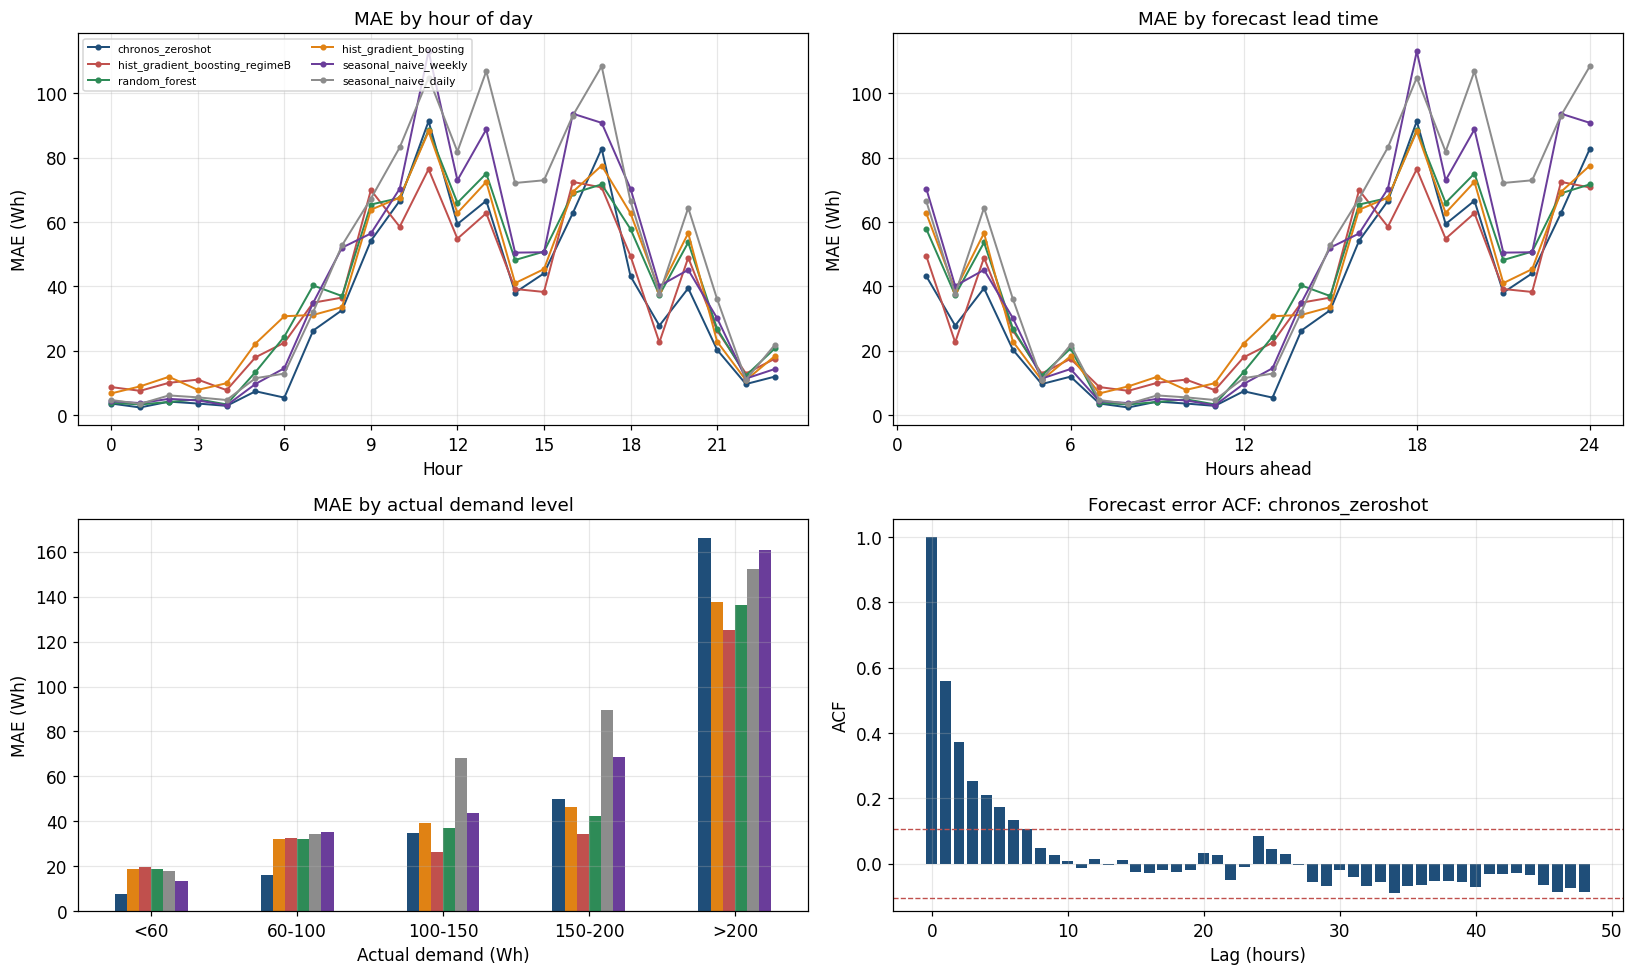

In [10]:
diagnostics = forecasts.copy()
diagnostics["error"] = diagnostics["actual"] - diagnostics["prediction"]
diagnostics["abs_error"] = diagnostics["error"].abs()
diagnostics["hour"] = diagnostics["timestamp"].dt.hour

top_models = list(scores.nsmallest(min(6, len(scores)), "MAE")["model"])
subset = diagnostics[diagnostics["model"].isin(top_models)]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
palette = dict(zip(top_models,
                   ["#1f4e79", "#c0504d", "#2e8b57", "#e08214",
                    "#6a3d9a", "#8c8c8c"]))

by_hour = subset.groupby(["model", "hour"])["abs_error"].mean().unstack(0)
for model in top_models:
    axes[0, 0].plot(by_hour.index, by_hour[model], marker="o", markersize=3,
                    color=palette[model], label=model, linewidth=1.3)
axes[0, 0].set(title="MAE by hour of day", xlabel="Hour", ylabel="MAE (Wh)",
               xticks=range(0, 24, 3))
axes[0, 0].legend(fontsize=7, ncol=2)

by_step = subset.groupby(["model", "step"])["abs_error"].mean().unstack(0)
for model in top_models:
    axes[0, 1].plot(by_step.index, by_step[model], marker="o", markersize=3,
                    color=palette[model], linewidth=1.3)
axes[0, 1].set(title="MAE by forecast lead time", xlabel="Hours ahead",
               ylabel="MAE (Wh)", xticks=range(0, 25, 6))

bins = [0, 60, 100, 150, 200, 10_000]
labels = ["<60", "60-100", "100-150", "150-200", ">200"]
subset = subset.assign(level=pd.cut(subset["actual"], bins=bins, labels=labels))
by_level = subset.groupby(["model", "level"], observed=True)["abs_error"].mean().unstack(0)
by_level.plot(kind="bar", ax=axes[1, 0],
              color=[palette[m] for m in by_level.columns], legend=False)
axes[1, 0].set(title="MAE by actual demand level", xlabel="Actual demand (Wh)",
               ylabel="MAE (Wh)")
axes[1, 0].tick_params(axis="x", rotation=0)

best_model = scores.iloc[0]["model"]
best_errors = errors[best_model]
error_acf = acf(best_errors, nlags=48)
axes[1, 1].bar(range(len(error_acf)), error_acf, color=PRIMARY)
bound = 1.96 / np.sqrt(len(best_errors))
axes[1, 1].axhline(bound, color=SECONDARY, linestyle="--", linewidth=0.9)
axes[1, 1].axhline(-bound, color=SECONDARY, linestyle="--", linewidth=0.9)
axes[1, 1].set(title=f"Forecast error ACF: {best_model}",
               xlabel="Lag (hours)", ylabel="ACF")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "30_error_diagnostics.png")
plt.show()

by_hour.to_csv(METRICS_DIR / "part8_error_by_hour.csv")
by_level.to_csv(METRICS_DIR / "part8_error_by_level.csv")


In [11]:
ljung_rows = []
for model in top_models:
    result = acorr_ljungbox(errors[model], lags=[24, 48], return_df=True)
    ljung_rows.append({"model": model,
                       "LB stat (24)": round(result.loc[24, "lb_stat"], 2),
                       "p (24)": round(result.loc[24, "lb_pvalue"], 4),
                       "p (48)": round(result.loc[48, "lb_pvalue"], 4),
                       "error ACF lag 24": round(acf(errors[model], nlags=24)[24], 3)})

ljung = pd.DataFrame(ljung_rows)
ljung["structure remaining"] = np.where(ljung["p (24)"] < 0.05,
                                        "yes - exploitable", "no - noise")
ljung.to_csv(METRICS_DIR / "part8_error_autocorrelation.csv", index=False)

print("Ljung-Box on forecast errors (H0: errors are independent)")
print("=" * 92)
print(ljung.to_string(index=False))


Ljung-Box on forecast errors (H0: errors are independent)
                         model  LB stat (24)  p (24)  p (48)  error ACF lag 24 structure remaining
              chronos_zeroshot        217.19     0.0     0.0             0.086   yes - exploitable
hist_gradient_boosting_regimeB        188.54     0.0     0.0             0.016   yes - exploitable
                 random_forest        216.09     0.0     0.0            -0.006   yes - exploitable
        hist_gradient_boosting        170.42     0.0     0.0             0.064   yes - exploitable
         seasonal_naive_weekly        381.40     0.0     0.0             0.035   yes - exploitable
          seasonal_naive_daily        299.77     0.0     0.0            -0.282   yes - exploitable


In [12]:
peak_threshold = 200
peaks = diagnostics[diagnostics["actual"] > peak_threshold]

peak_summary = (peaks.groupby("model")
                .agg(hours=("actual", "size"),
                     mean_actual=("actual", "mean"),
                     mean_predicted=("prediction", "mean"),
                     mean_abs_error=("abs_error", "mean"))
                .assign(shortfall=lambda d: d["mean_actual"] - d["mean_predicted"])
                .sort_values("mean_abs_error"))

print(f"Performance on the {peaks['model'].value_counts().iloc[0]} hours "
      f"above {peak_threshold} Wh")
print("=" * 86)
print(peak_summary.round(1).to_string())
peak_summary.to_csv(METRICS_DIR / "part8_peak_performance.csv")

quiet = diagnostics[diagnostics["actual"] < 60]
print(f"\nMAE on quiet hours (<60 Wh) versus peak hours (>{peak_threshold} Wh)")
comparison = pd.DataFrame({
    "quiet MAE": quiet.groupby("model")["abs_error"].mean(),
    "peak MAE": peaks.groupby("model")["abs_error"].mean(),
}).assign(ratio=lambda d: d["peak MAE"] / d["quiet MAE"]).sort_values("peak MAE")
print(comparison.round(1).to_string())


Performance on the 37 hours above 200 Wh
                                hours  mean_actual  mean_predicted  mean_abs_error  shortfall
model                                                                                        
hist_gradient_boosting_regimeB     37        278.0           153.2           125.3      124.8
random_forest                      37        278.0           141.5           136.5      136.5
hist_gradient_boosting             37        278.0           143.0           137.7      135.0
naive                              37        278.0           201.1           152.2       76.9
drift                              37        278.0           201.8           152.2       76.2
seasonal_naive_daily               37        278.0           152.0           152.5      126.0
seasonal_naive_weekly              37        278.0           118.5           160.9      159.5
chronos_zeroshot                   37        278.0           112.8           166.1      165.2
mean               

## 7. Forecast plots


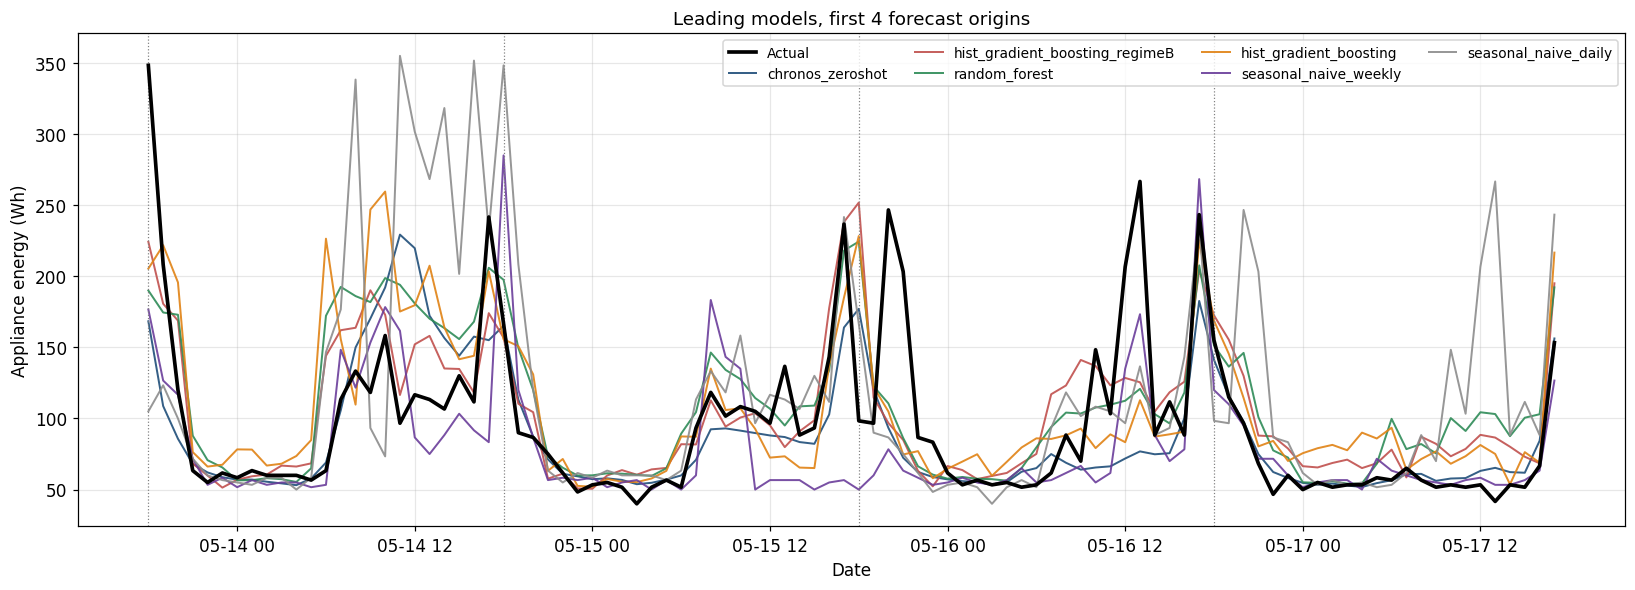

In [13]:
def plot_all_forecasts(frame, models, n_origins=4):
    """Overlay the leading models across the first few test days."""
    subset = frame[(frame["model"].isin(models)) &
                   (frame["origin_id"] <= n_origins)]
    actual = (subset[subset["model"] == models[0]]
              .sort_values("timestamp").set_index("timestamp")["actual"])

    fig, ax = plt.subplots(figsize=(15, 5.5))
    ax.plot(actual.index, actual.values, color="black", linewidth=2.4,
            label="Actual", zorder=5)

    for model in models:
        model_data = subset[subset["model"] == model].sort_values("timestamp")
        ax.plot(model_data["timestamp"], model_data["prediction"],
                color=palette.get(model, "#999"), linewidth=1.3,
                alpha=0.9, label=model)

    for origin_id in range(1, n_origins + 1):
        boundary = subset[subset["origin_id"] == origin_id]["timestamp"].min()
        ax.axvline(boundary, color="grey", linestyle=":", linewidth=0.8)

    ax.set(title=f"Leading models, first {n_origins} forecast origins",
           ylabel="Appliance energy (Wh)", xlabel="Date")
    ax.legend(ncol=4, fontsize=9)
    fig.tight_layout()
    return fig


fig = plot_all_forecasts(forecasts, top_models, n_origins=4)
fig.savefig(FIGURE_DIR / "31_all_model_forecasts.png")
plt.show()


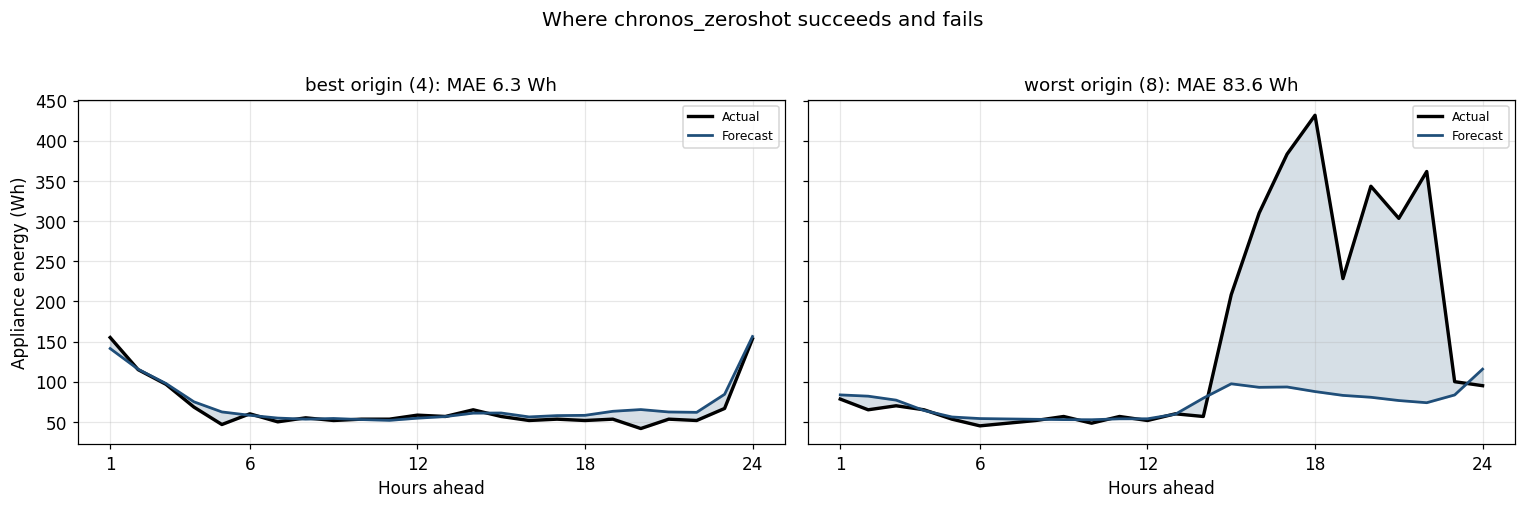

Best origin  : 4
Worst origin : 8


In [14]:
def plot_best_worst_days(frame, model):
    """The origins where the leading model did best and worst."""
    origin_scores = (per_origin[per_origin["model"] == model]
                     .set_index("origin_id")["MAE"])
    best_origin, worst_origin = origin_scores.idxmin(), origin_scores.idxmax()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

    for ax, origin_id, label in [(axes[0], best_origin, "best"),
                                 (axes[1], worst_origin, "worst")]:
        day = frame[(frame["model"] == model) &
                    (frame["origin_id"] == origin_id)].sort_values("step")
        ax.plot(day["step"], day["actual"], color="black", linewidth=2.2,
                label="Actual")
        ax.plot(day["step"], day["prediction"], color=PRIMARY, linewidth=1.8,
                label="Forecast")
        ax.fill_between(day["step"], day["actual"], day["prediction"],
                        color=PRIMARY, alpha=0.18)
        ax.set(title=f"{label} origin ({origin_id}): "
                     f"MAE {origin_scores[origin_id]:.1f} Wh",
               xlabel="Hours ahead", xticks=[1, 6, 12, 18, 24])
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Appliance energy (Wh)")
    fig.suptitle(f"Where {model} succeeds and fails", y=1.02)
    fig.tight_layout()
    return fig, best_origin, worst_origin


fig, best_origin, worst_origin = plot_best_worst_days(forecasts, best_model)
fig.savefig(FIGURE_DIR / "32_best_worst_origins.png")
plt.show()

print(f"Best origin  : {best_origin}")
print(f"Worst origin : {worst_origin}")


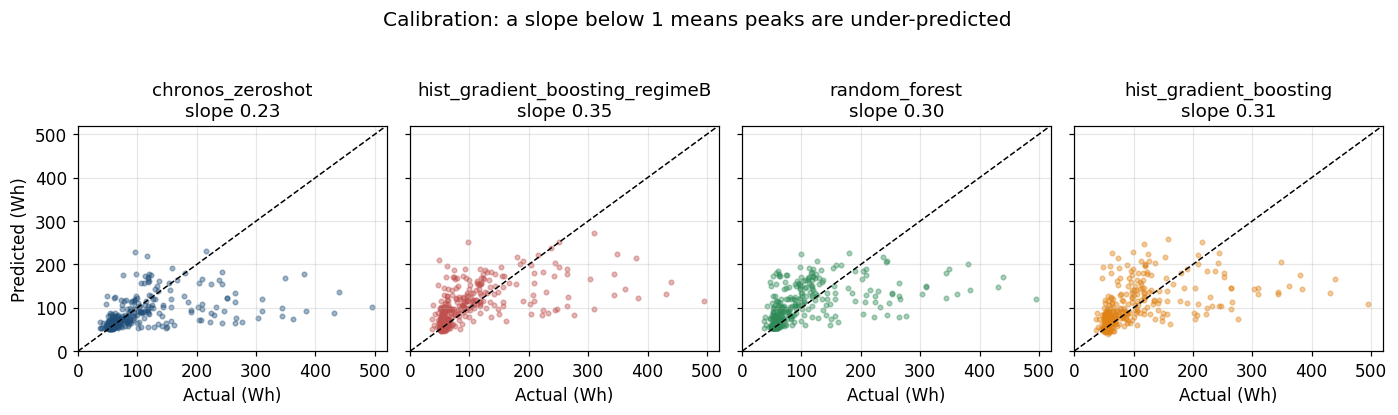

  chronos_zeroshot           regression slope 0.228
  hist_gradient_boosting_regimeB regression slope 0.346
  random_forest              regression slope 0.304
  hist_gradient_boosting     regression slope 0.310


In [15]:
def plot_calibration(frame, models):
    """Predicted against actual, to reveal systematic under-prediction."""
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.6), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)

    limit = frame["actual"].max() * 1.05

    for ax, model in zip(axes, models):
        model_data = frame[frame["model"] == model]
        ax.scatter(model_data["actual"], model_data["prediction"], s=9,
                   alpha=0.4, color=palette.get(model, "#999"))
        ax.plot([0, limit], [0, limit], color="black", linestyle="--",
                linewidth=1.0)

        slope = np.polyfit(model_data["actual"], model_data["prediction"], 1)[0]
        ax.set(title=f"{model}\nslope {slope:.2f}", xlabel="Actual (Wh)",
               xlim=(0, limit), ylim=(0, limit))

    axes[0].set_ylabel("Predicted (Wh)")
    fig.suptitle("Calibration: a slope below 1 means peaks are under-predicted",
                 y=1.04)
    fig.tight_layout()
    return fig


fig = plot_calibration(forecasts, top_models[:4])
fig.savefig(FIGURE_DIR / "33_calibration.png")
plt.show()

for model in top_models[:4]:
    model_data = forecasts[forecasts["model"] == model]
    slope = np.polyfit(model_data["actual"], model_data["prediction"], 1)[0]
    print(f"  {model:<26} regression slope {slope:.3f}")


## 8. Summary table for the report

A single table combining accuracy, stability, significance and cost, which is
what Question 6 needs.


In [16]:
final = scores[["rank", "family", "model", "MAE", "RMSE", "MASE",
                "Bias", "skill vs benchmark %"]].copy()
final = final.merge(stability[["std"]].rename(columns={"std": "MAE std"}),
                    left_on="model", right_index=True, how="left")

if BEST_BENCHMARK:
    significance = {row["model"]: row["beats benchmark"]
                    for _, row in benchmark_tests.iterrows()}
    final["vs benchmark"] = final["model"].map(significance).fillna("(reference)")

final.to_csv(METRICS_DIR / "part8_final_table.csv", index=False)

print("Final comparison table")
print("=" * 118)
print(final.round(2).to_string(index=False))


Final comparison table
 rank           family                          model    MAE   RMSE  MASE   Bias  skill vs benchmark %  MAE std            vs benchmark
    1       foundation               chronos_zeroshot  33.58  67.53  0.63 -18.05                 21.77    22.46       not significantly
    2 machine learning hist_gradient_boosting_regimeB  36.55  61.51  0.69   3.00                 14.84    18.79       not significantly
    3 machine learning                  random_forest  39.37  64.06  0.74   2.22                  8.29    19.52       not significantly
    4 machine learning         hist_gradient_boosting  40.03  65.80  0.75   0.73                  6.74    18.89       not significantly
    5        benchmark          seasonal_naive_weekly  42.92  79.67  0.80 -12.62                  0.00    28.24             (reference)
    6        benchmark           seasonal_naive_daily  48.39  85.79  0.91   1.67                -12.75    24.51       not significantly
    7        benchmark   

## 9. Summary of Part 8

- Every model pooled onto identical origins and scored on identical metrics
- Ranked comparison with per-origin variability shown as error bars
- Pairwise Diebold–Mariano matrix, so the ranking reads as groups rather than an order
- Explicit test of every model against the strongest benchmark
- Error diagnostics by hour, lead time, demand level and error autocorrelation
- Ljung–Box on forecast errors to test for unexploited structure
- Peak versus quiet-hour performance, and calibration slopes
- Best and worst forecast days for the leading model

**Files written**

- `outputs/metrics/part8_master_comparison.csv`, `part8_final_table.csv`
- `outputs/metrics/part8_by_origin.csv`, `part8_vs_benchmark.csv`
- `outputs/metrics/part8_dm_pvalue_matrix.csv`
- `outputs/metrics/part8_error_by_hour.csv`, `part8_error_by_level.csv`
- `outputs/metrics/part8_error_autocorrelation.csv`, `part8_peak_performance.csv`
- `outputs/figures/28` to `33`
